# Демо DINOv2: видео из независимого теста

Шесть **видео (групп источника)** из `data/splits/vk_owner_holdout/test.jsonl`: три случая, где все три метки совпали, и три случая с ошибкой. Для каждого видео показываются короткий фрагмент и **все четыре кадра каждого тестового окна, подаваемые в DINOv2**. Результат для видео получается усреднением логитов его окон, как в тестовом скрипте.

**Данные:** в `sports_training_bundle` хранятся извлечённые кадры (обычно 5 кадр/с), а исходные MP4 отсутствуют. Видео ниже — воспроизведение сохранённых кадров без звука, собранное для показа. В модель поступают только четыре выбранных кадра окна после `Resize(256) → CenterCrop(224) → Normalize`; заголовок и описание используются лишь для пояснения разметки. Метки пола и возраста относятся к **категории соревнования**, а не к распознаванию людей по внешности. Тестовые метки получены из описаний событий и могут содержать ошибки.

**Упаковка репозитория:** здесь используются те же шесть видео и тот же checkpoint, что в исходном демо. Полный архив для показа не нужен: кадры этих случаев находятся в `demo/sample_bundle/`. Локальные веса в `data/models/` и `outputs/*/checkpoint.pt` исключены из Git; порядок их переноса описан в `demo/README.md`. Основной кандидат итогового отчёта — 1f; это демо, как и раньше, показывает проверенный вариант 4f.

In [1]:
from pathlib import Path
import hashlib
import json
import subprocess
import sys

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import Video, display, Markdown
from torch import nn

# Ноутбук можно запускать из корня проекта или из подкаталога.
PROJECT = next((p for p in [Path.cwd(), *Path.cwd().parents]
                if (p / "sports_training_bundle").is_dir()
                and (p / "scripts/train_vk_bundle.py").is_file()), None)
if PROJECT is None:
    raise FileNotFoundError("Запустите ноутбук внутри каталога проекта")
sys.path[:0] = [str(PROJECT / "src"), str(PROJECT / "scripts")]
from sports_video.models import VideoClassifier
from train_vk_bundle import BundleDataset, CLASSES, HEADS

CHECKPOINT_DIR = PROJECT / "outputs/vk_owner_dinov2_4f"
SPLIT = PROJECT / "data/splits/vk_owner_holdout/test.jsonl"
BUNDLE = (PROJECT / "sports_training_bundle" if (PROJECT / "sports_training_bundle/frames").is_dir()
          else PROJECT / "demo/sample_bundle")
PREVIEWS = PROJECT / "outputs/vk_dinov2_demo_clips"
config = json.loads((CHECKPOINT_DIR / "config.json").read_text(encoding="utf-8"))
assert config["model"] == "dinov2_small" and config["frames"] == 4
assert hashlib.sha256(SPLIT.read_bytes()).hexdigest() == config["audit"]["sha256"]["test"]
rows = [json.loads(line) for line in SPLIT.read_text(encoding="utf-8").splitlines()]
by_group = {}
for row in rows:
    by_group.setdefault(row["source_group_id"], []).append(row)
print(f"DINOv2-S • {config['frames']} кадра на окно • test: {len(rows)} окон, {len(by_group)} видео")

DINOv2-S • 4 кадра на окно • test: 165 окон, 61 видео


## Выбранные видео

Подбор фиксирован для повторяемого показа. Столбец «по сохранённому тесту» помогает заранее найти удачные и неудачные случаи; ниже прогноз **пересчитывается из кадров и чекпоинта**. Каждое видео содержит 2–3 тестовых окна.

In [2]:
CASES = [
    ("1c8b75b8adec1e595d35", "Удачный: футбол"),
    ("77f60999d0f06bf0501c", "Удачный: баскетбол"),
    ("336c6406e79968898db2", "Удачный: теннис"),
    ("cb98003a92a7fda10674", "Ошибка: волейбол"),
    ("650c9d7503e92887edbe", "Ошибка: гандбол"),
    ("3150cdbe4b1a0b89b836", "Ошибка: настольный теннис"),
]
saved = {p["source_group_id"]: p for p in json.loads(
    (CHECKPOINT_DIR / "group_predictions.json").read_text(encoding="utf-8"))}
assert all(group in by_group and group in saved for group, _ in CASES)
summary = []
for group, name in CASES:
    item = saved[group]
    summary.append({"случай": name, "окон": len(by_group[group]),
                    "истина (спорт / пол / возраст)": " / ".join(item[k]["true"] for k in CLASSES),
                    "по сохранённому тесту": " / ".join(item[k]["pred"] for k in CLASSES)})
display(pd.DataFrame(summary))

,случай,окон,истина (спорт / пол / возраст),по сохранённому тесту
0,Удачный: футбол,3,football / men / under_18,football / men / under_18
1,Удачный: баскетбол,3,basketball / men / under_18,basketball / men / under_18
2,Удачный: теннис,3,tennis / women / adult_18_plus,tennis / women / adult_18_plus
3,Ошибка: волейбол,3,volleyball / men / adult_18_plus,basketball / women / under_18
4,Ошибка: гандбол,2,handball / men / under_18,basketball / men / under_18
5,Ошибка: настольный теннис,3,table_tennis / women / adult_18_plus,table_tennis / women / under_18


## Загрузка DINOv2 и подготовка входа

Используется чекпоинт `vk_owner_dinov2_4f`. Выбор 4 кадров и преобразование изображения берутся из `BundleDataset`, который использовался при тестировании. На рисунках нормализация обращается **только для отображения**; в модель поступает исходный нормализованный тензор.

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
weights = PROJECT / config["weights"]
if not weights.is_dir():
    raise FileNotFoundError(f"Нет локальных весов DINOv2: {weights}")
model = VideoClassifier("dinov2_small", pretrained=False,
                        freeze=config["freeze"], weights=str(weights))
model.heads["sport_label"] = nn.Linear(model.width, len(CLASSES["sport"]))
state = torch.load(CHECKPOINT_DIR / "checkpoint.pt", map_location="cpu", weights_only=True)
model.load_state_dict(state)
model.to(device).eval()
dataset = BundleDataset(BUNDLE, rows, "dinov2_small", config["frames"], False)
row_index = {row["clip_id"]: i for i, row in enumerate(rows)}
print(f"Устройство: {device}; чекпоинт: {CHECKPOINT_DIR.name}")

2026-10-01 20:08:31.404873: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1790874511.417839  244563 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1790874511.421503  244563 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-10-01 20:08:31.434873: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Устройство: cuda; чекпоинт: vk_owner_dinov2_4f


In [4]:
def selected_indices(row):
    # Та же формула, что в BundleDataset.__getitem__ для DINOv2.
    return np.linspace(0, len(row["frames"]) - 1, config["frames"] + 2)[1:-1].round().astype(int)


def make_preview(row):
    """H.264 из всех сохранённых кадров одного окна (для воспроизведения, не для модели)."""
    PREVIEWS.mkdir(parents=True, exist_ok=True)
    path = PREVIEWS / f"{row['clip_id']}.mp4"
    if not path.is_file():
        folder = BUNDLE / Path(row["frames"][0]).parent
        command = ["ffmpeg", "-y", "-loglevel", "error", "-framerate", "5",
                   "-start_number", "1", "-i", str(folder / "frame_%03d.jpg"),
                   "-frames:v", str(len(row["frames"])), "-c:v", "libx264",
                   "-pix_fmt", "yuv420p", "-movflags", "+faststart", str(path)]
        subprocess.run(command, check=True)
    return path


def show_model_frames(group_rows):
    fig, axes = plt.subplots(len(group_rows), config["frames"],
                             figsize=(14, 2.65 * len(group_rows)), squeeze=False)
    mean = torch.tensor((0.485, 0.456, 0.406))[:, None, None]
    std = torch.tensor((0.229, 0.224, 0.225))[:, None, None]
    for i, row in enumerate(group_rows):
        x, _, _ = dataset[row_index[row["clip_id"]]]
        indices = selected_indices(row)
        for j, frame in enumerate(x):
            rgb = ((frame * std + mean).clamp(0, 1).permute(1, 2, 0).numpy())
            axes[i, j].imshow(rgb)
            axes[i, j].set_title(f"t ≈ {indices[j] / 5:.1f} с", fontsize=10)
            axes[i, j].axis("off")
        axes[i, 0].set_ylabel(f"окно {i+1}\n{row['start_s']} с", rotation=0,
                              labelpad=45, va="center")
    fig.suptitle("Кадры 224×224 после Resize + CenterCrop; Normalize обращён для показа", fontsize=12)
    fig.tight_layout()
    display(fig)
    plt.close(fig)


@torch.inference_mode()
def predict_video(group_rows):
    # Точно как evaluate(): среднее логитов окон, затем argmax по каждому выходу.
    logits = {key: [] for key in CLASSES}
    for row in group_rows:
        x, _, _ = dataset[row_index[row["clip_id"]]]
        with torch.autocast(device_type=device.type, enabled=device.type == "cuda"):
            output = model(x.unsqueeze(0).to(device))
        for key, head in HEADS.items():
            logits[key].append(output[head][0].float().cpu())
    result = {}
    for key, classes in CLASSES.items():
        mean = torch.stack(logits[key]).mean(0)
        probabilities = mean.softmax(0)
        result[key] = (classes[probabilities.argmax().item()],
                       probabilities.max().item())
    return result

## Воспроизведение и результаты

В каждом блоке видео воспроизводит **первое тестовое окно** группы. Таблица кадров ниже охватывает **все окна этой группы**, из которых вычисляется итоговый ответ. Время на кадре указано относительно начала окна. Значение softmax — оценка самой модели, без калибровки вероятностей.

### Удачный: футбол · ЮФЛ Юг U-15. 23 тур. ФШ им. Л.Слуцкого – Краснодар

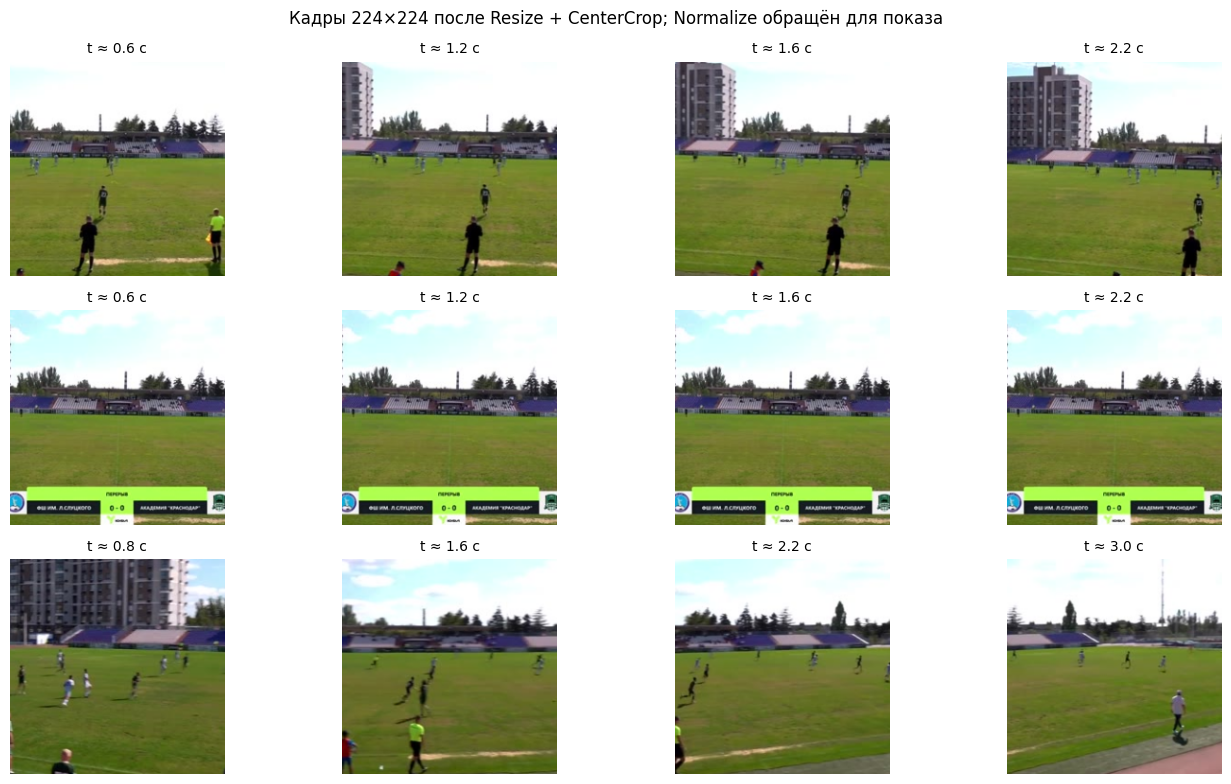

,задача,разметка,прогноз DINOv2,softmax,совпало
0,Вид спорта,football,football,1.000,✓
1,Категория пола,men,men,0.853,✓
2,Категория возраста,under_18,under_18,0.972,✓


### Удачный: баскетбол · 2019-03-29 Boys U15. Israel vs Russia. International Basketball Tournament, Moscow Russia

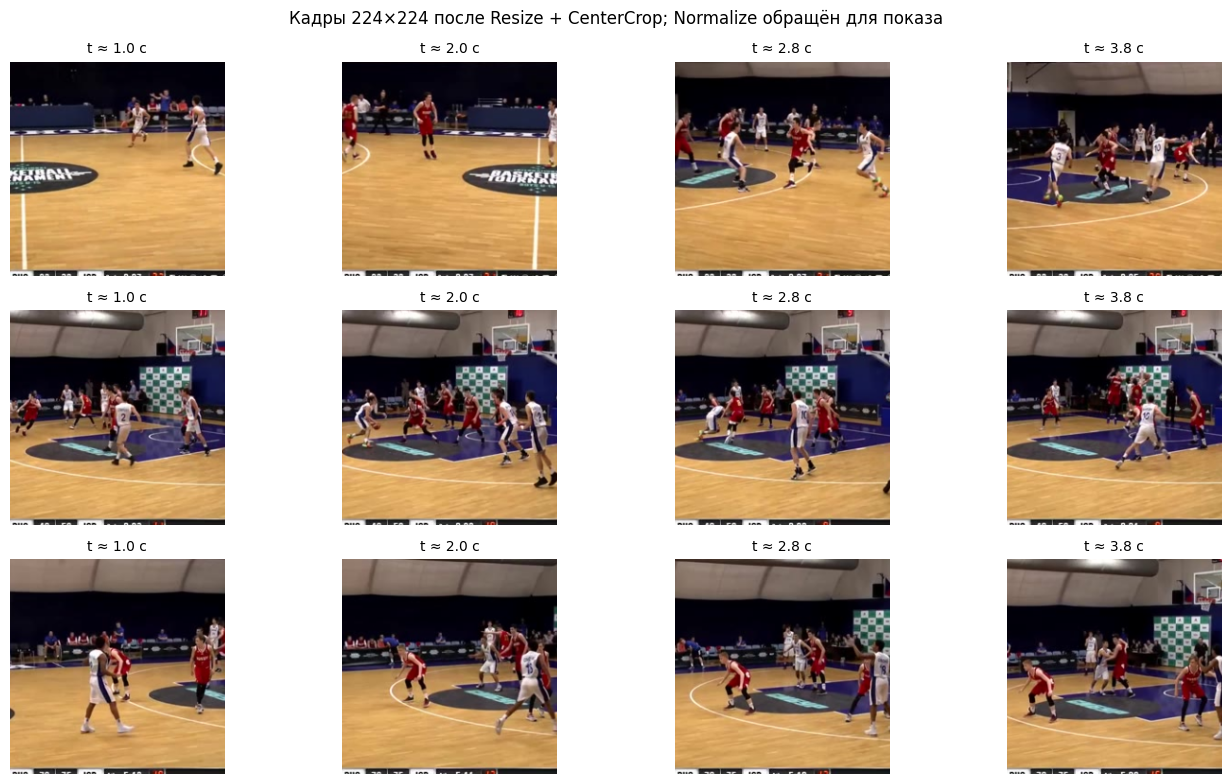

,задача,разметка,прогноз DINOv2,softmax,совпало
0,Вид спорта,basketball,basketball,0.993,✓
1,Категория пола,men,men,0.587,✓
2,Категория возраста,under_18,under_18,0.717,✓


### Удачный: теннис · Мию Като/Эллен Перес х Софья Лансере/Татьяна Прозорова | WTA 500 Сингапур | 1/4 финала | Трансляция матча | 12:00

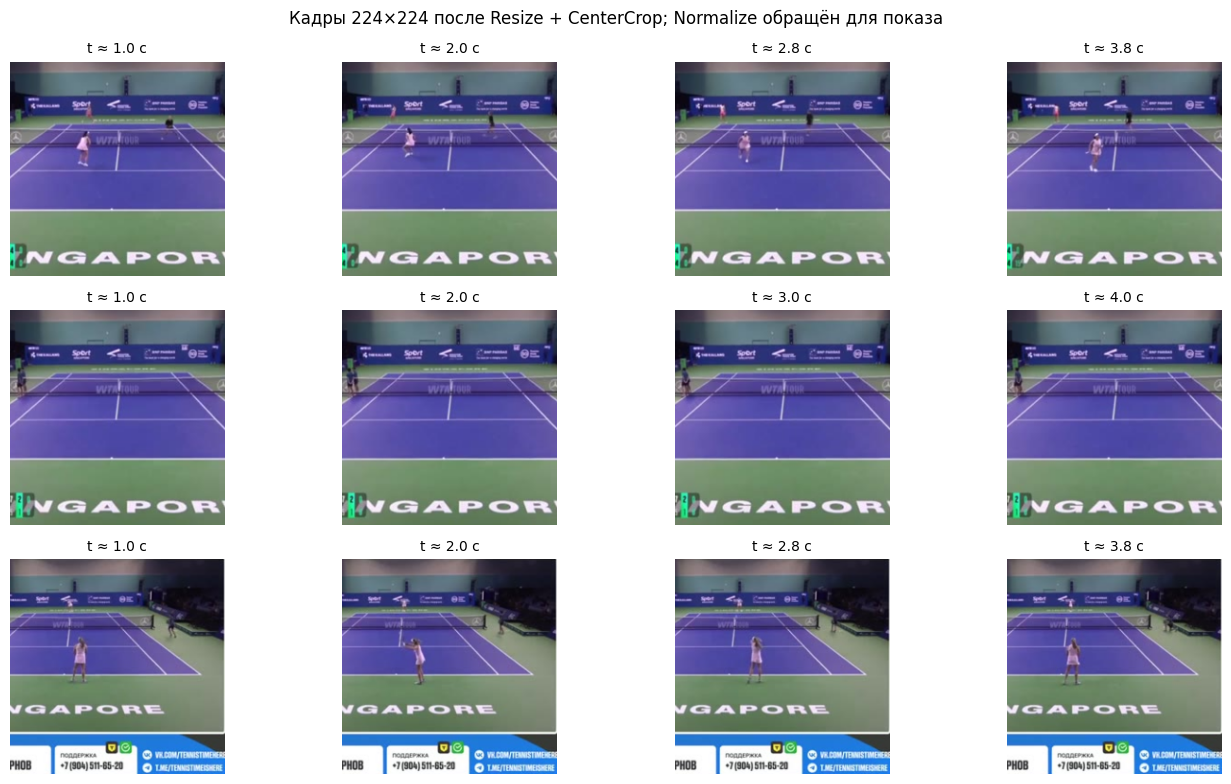

,задача,разметка,прогноз DINOv2,softmax,совпало
0,Вид спорта,tennis,tennis,0.994,✓
1,Категория пола,women,women,0.845,✓
2,Категория возраста,adult_18_plus,adult_18_plus,0.812,✓


### Ошибка: волейбол · Матч! Мужской волейбол. 9 vs 7

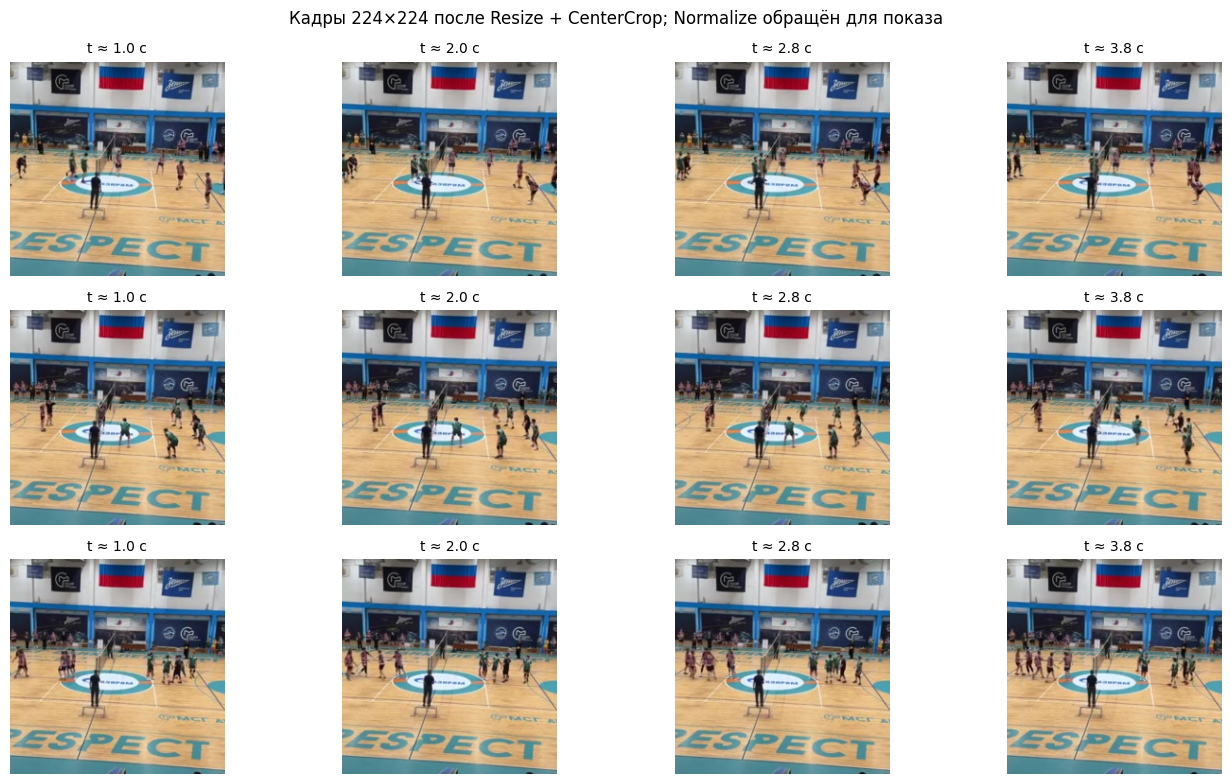

,задача,разметка,прогноз DINOv2,softmax,совпало
0,Вид спорта,volleyball,basketball,0.699,✗
1,Категория пола,men,women,0.743,✗
2,Категория возраста,adult_18_plus,under_18,0.678,✗


### Ошибка: гандбол · > 🤾‍♂️ Открытое первенство по гандболу среди юношей 2013 г.р. и младше >  > Матч №1  > 🔵 СШ «АК Буре» (г. Казань)  &

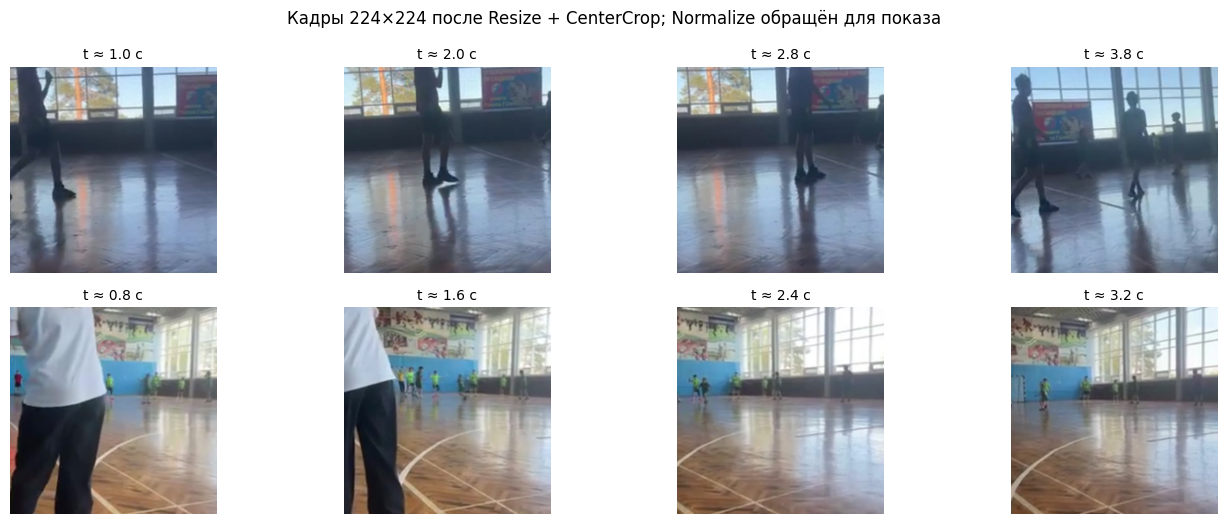

,задача,разметка,прогноз DINOv2,softmax,совпало
0,Вид спорта,handball,basketball,0.446,✗
1,Категория пола,men,men,0.984,✓
2,Категория возраста,under_18,under_18,0.548,✓


### Ошибка: настольный теннис · 54-й турнир по настольному теннису серии Мастер-Тур среди женщин в формате 7x7 ТТ

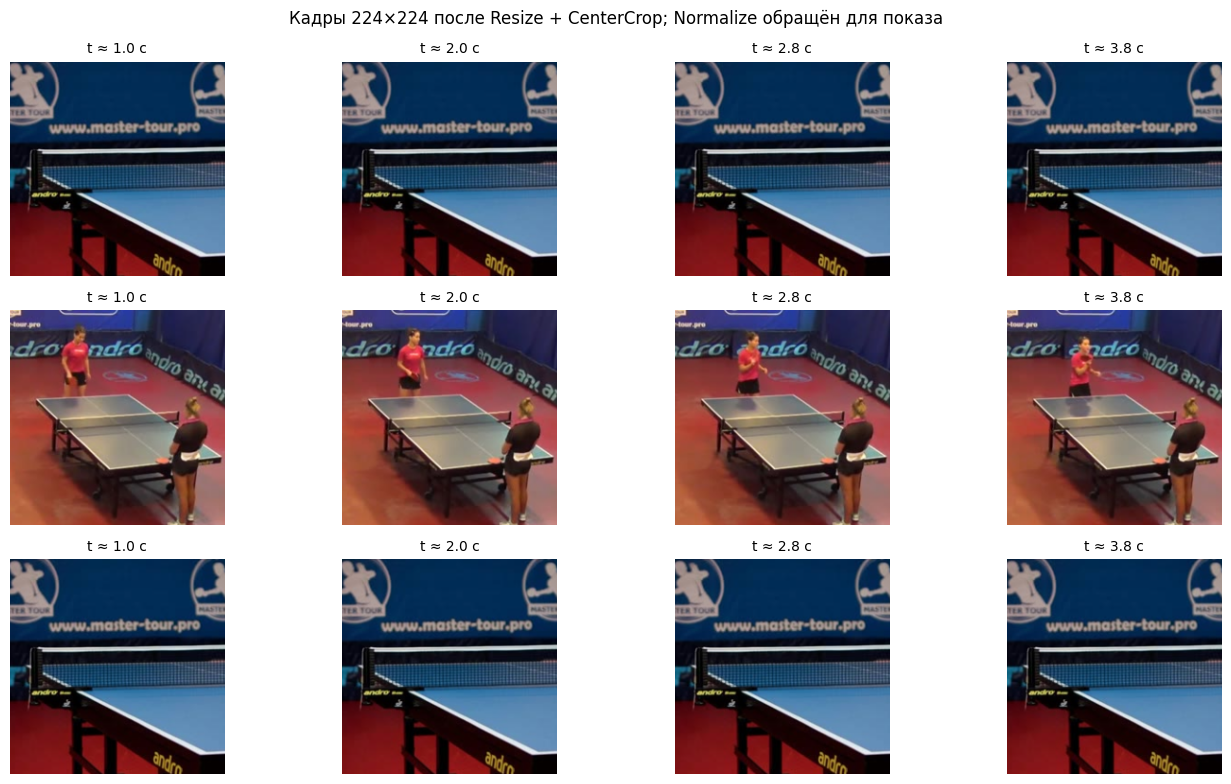

,задача,разметка,прогноз DINOv2,softmax,совпало
0,Вид спорта,table_tennis,table_tennis,0.995,✓
1,Категория пола,women,women,0.914,✓
2,Категория возраста,adult_18_plus,under_18,0.736,✗


In [5]:
results = []
for group, name in CASES:
    group_rows = by_group[group]
    first = group_rows[0]
    display(Markdown(f"### {name} · {first['title']}"))
    display(Video(filename=str(make_preview(first)), embed=True,
                  html_attributes="controls width=640"))
    show_model_frames(group_rows)
    prediction = predict_video(group_rows)
    comparison = []
    for key, label in (("sport", "Вид спорта"), ("gender", "Категория пола"),
                       ("age", "Категория возраста")):
        expected = first[key]
        actual, score = prediction[key]
        comparison.append({"задача": label, "разметка": expected,
                           "прогноз DINOv2": actual, "softmax": round(score, 3),
                           "совпало": "✓" if actual == expected else "✗"})
    display(pd.DataFrame(comparison))
    status = all(prediction[key][0] == first[key] for key in CLASSES)
    results.append({"видео": name, "окон": len(group_rows),
                    "все три метки совпали": status,
                    **{f"{key}: истина → прогноз": f"{first[key]} → {prediction[key][0]}"
                       for key in CLASSES}})



## Сводка по шести выбранным случаям

Это **качественные примеры**, специально выбранные по результатам теста. Доли верных ответов на них не являются оценкой качества на всей выборке. Для полной оценки см. `outputs/vk_owner_dinov2_4f/test_metrics.json`.

In [6]:
display(pd.DataFrame(results))

,видео,окон,все три метки совпали,sport: истина → прогноз,gender: истина → прогноз,age: истина → прогноз
0,Удачный: футбол,3,True,football → football,men → men,under_18 → under_18
1,Удачный: баскетбол,3,True,basketball → basketball,men → men,under_18 → under_18
2,Удачный: теннис,3,True,tennis → tennis,women → women,adult_18_plus → adult_18_plus
3,Ошибка: волейбол,3,False,volleyball → basketball,men → women,adult_18_plus → under_18
4,Ошибка: гандбол,2,False,handball → basketball,men → men,under_18 → under_18
5,Ошибка: настольный теннис,3,False,table_tennis → table_tennis,women → women,adult_18_plus → under_18


In [7]:
assert len(results) == 6
for item, (group, _) in zip(results, CASES):
    for task in CLASSES:
        pair = item[f"{task}: истина → прогноз"]
        expected = f"{saved[group][task]['true']} → {saved[group][task]['pred']}"
        assert pair == expected, (group, task, pair, expected)
print("Проверка переноса: все 18 меток совпали с сохранёнными прогнозами исходного демо.")

Проверка переноса: все 18 меток совпали с сохранёнными прогнозами исходного демо.
